# Generate Images with Azure OpenAI and FLUX-1.1-pro

This notebook demonstrates how to generate an image with the **FLUX-1.1-pro** deployment in Azure AI Foundry, save the result locally, and display it in the notebook.

## Learning objectives

1. Install the required Python packages.
2. Configure the Azure AI endpoint, API key, and deployment.
3. collect and validate an image prompt.
4. Generate an image with FLUX-1.1-pro.
5. Save and display the generated image.

> **Security note:** Use only temporary lab credentials. Never commit real keys to GitHub or include them in screenshots or shared notebooks.

## Step 1: Install required packages

Install the pinned OpenAI SDK used by this lab, plus Pillow for image validation.

In [ ]:
%pip install --quiet openai==1.65.2 pillow requests

## Step 2: Import dependencies

The notebook uses the OpenAI-compatible client, base64 decoding, HTTP downloads, local file paths, Pillow image validation, and notebook display utilities.

In [ ]:
import base64
from pathlib import Path

import requests
from IPython.display import display
from openai import OpenAI
from PIL import Image

## Step 3: Configure Azure AI

Replace the key placeholder with the temporary key supplied by the instructor.

> **Tip:** Explore the different model types available in Azure AI.
>
> * **`gpt-5.4-mini`** → Chat model
> * **`FLUX-1.1-pro`** → Image-generation model

For this image-generation lab, use the deployed **`FLUX-1.1-pro`** model and its API key.

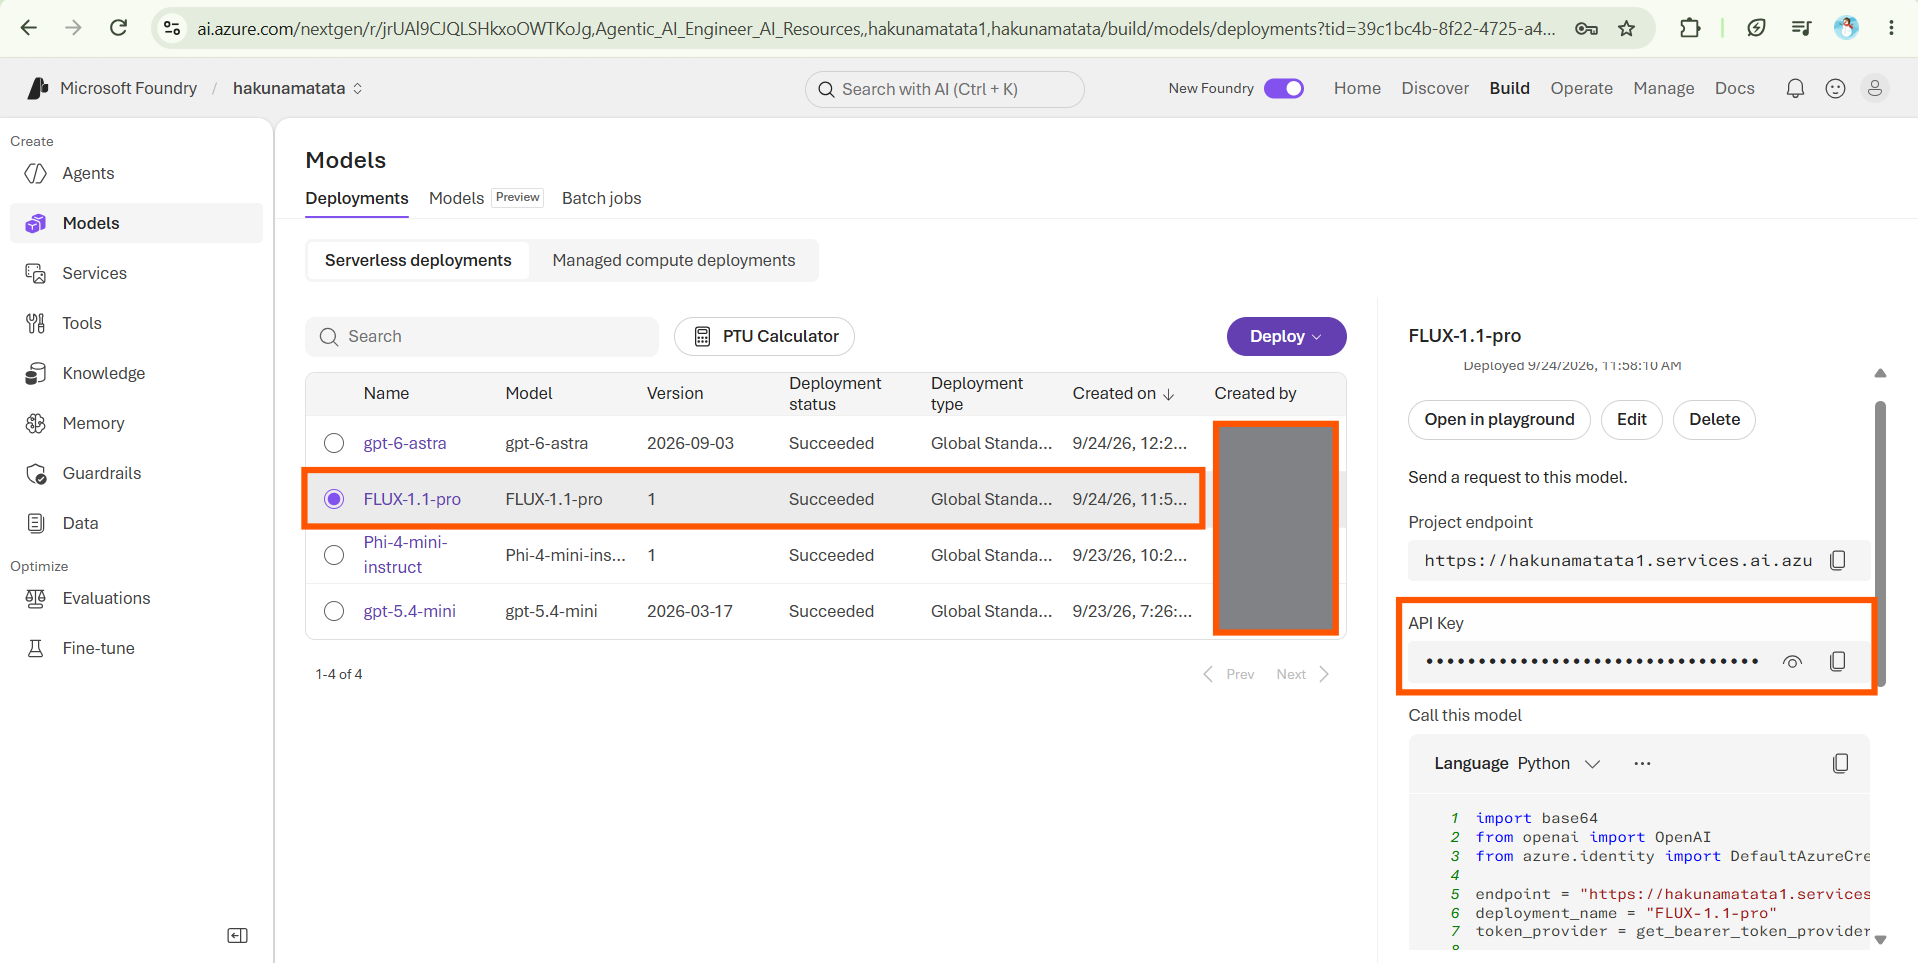


In [ ]:
azure_oai_endpoint = "https://hakunamatata1.services.ai.azure.com/openai/v1"
azure_oai_key = "replace_your_api_key"
azure_oai_deployment = "FLUX-1.1-pro"

if not azure_oai_endpoint.startswith("https://"):
    raise ValueError("The endpoint must start with https://")

if not azure_oai_endpoint.rstrip("/").endswith("/openai/v1"):
    raise ValueError("The endpoint must end with /openai/v1")

if not azure_oai_key or azure_oai_key.startswith("<"):
    raise ValueError("Replace the API key placeholder before continuing.")

if not azure_oai_deployment.strip():
    raise ValueError("The deployment name cannot be empty.")

print("Configuration validated.")
print(f"Deployment: {azure_oai_deployment}")

## Step 4: Create the model client

Create an OpenAI-compatible client that points to the Azure AI endpoint.

In [ ]:
client = OpenAI(
    base_url=azure_oai_endpoint,
    api_key=azure_oai_key,
)

print("Azure AI image client ready.")

## Step 5: Enter an image prompt

> **Note:** Enter the **full image prompt** in the input box at the top of the VS Code window and after it's done press *enter*

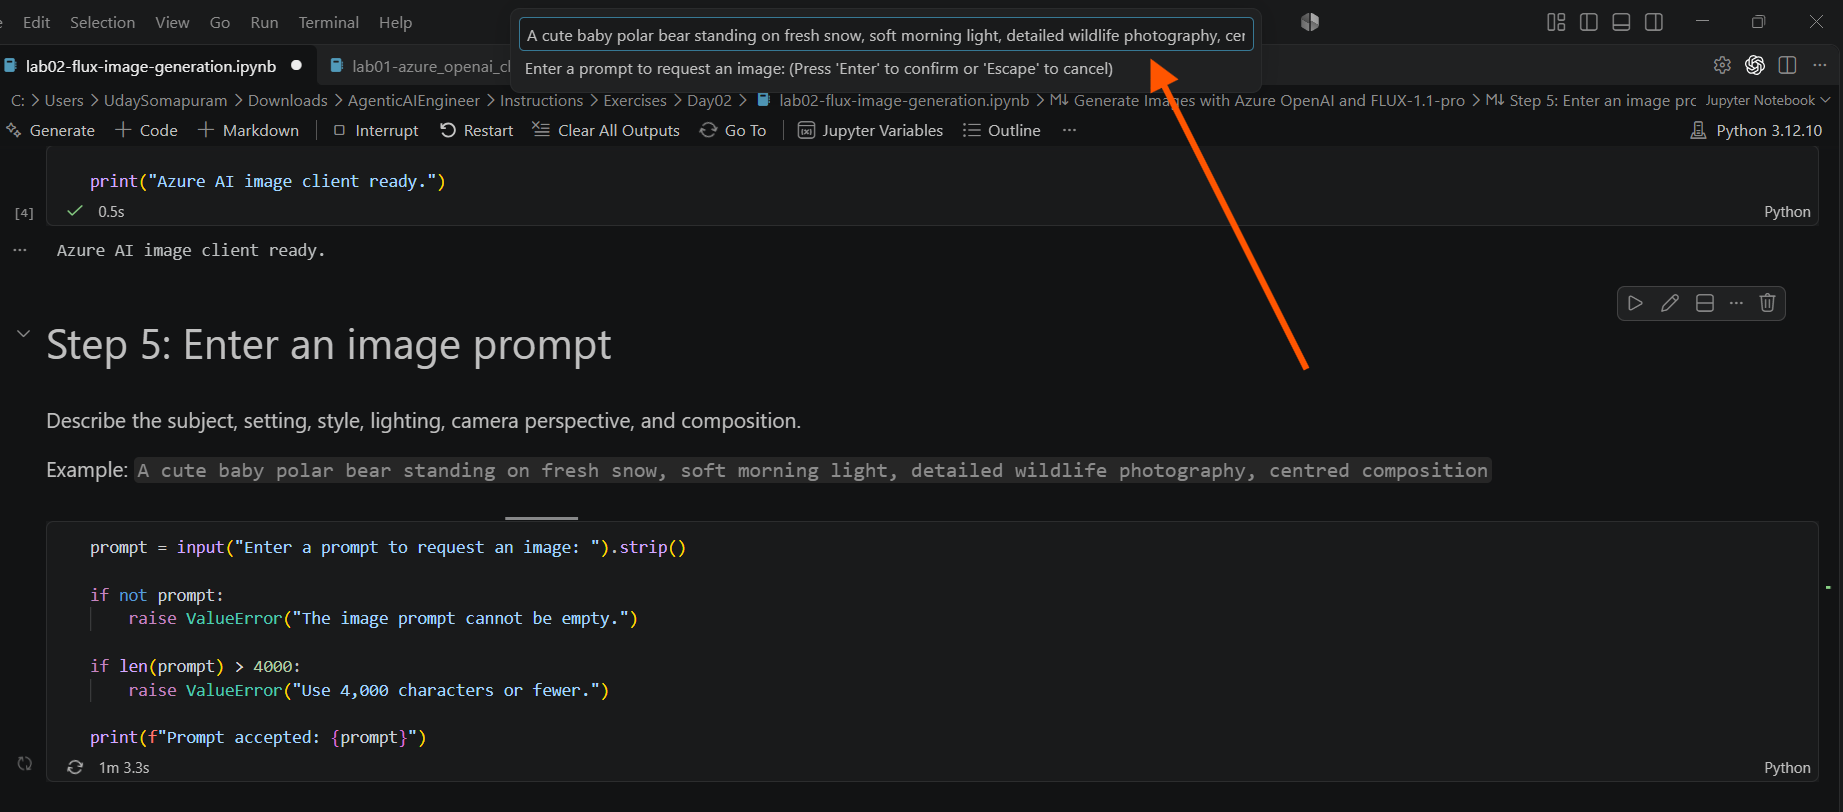


Describe the subject, setting, style, lighting, camera perspective, and composition.

**Example:** `A cute baby polar bear standing on fresh snow, soft morning light, detailed wildlife photography, centred composition`

In [ ]:
prompt = input("Enter a prompt to request an image: ").strip()

if not prompt:
    raise ValueError("The image prompt cannot be empty.")

if len(prompt) > 4000:
    raise ValueError("Use 4,000 characters or fewer.")

print(f"Prompt accepted: {prompt}")

## Step 6: Generate the image

Send the prompt to the FLUX-1.1-pro deployment and request one 1024 × 1024 image.

In [ ]:
try:
    image_response = client.images.generate(
        model=azure_oai_deployment,
        prompt=prompt,
        n=1,
        size="1024x1024",
    )
except Exception as exc:
    raise RuntimeError(
        "Image generation failed. Check the endpoint, key, deployment, and model access."
    ) from exc

if not image_response.data:
    raise RuntimeError("The model returned no image data.")

print("Image-generation response received.")

## Step 7: Save the generated image

The response may contain base64 image data or a downloadable URL. This step supports both formats and saves the result as `generated_image.png`.

In [ ]:
image_item = image_response.data[0]
image_base64 = getattr(image_item, "b64_json", None)
image_url = getattr(image_item, "url", None)
output_path = Path("generated_image.png").resolve()

if image_base64:
    try:
        image_bytes = base64.b64decode(image_base64, validate=True)
    except Exception as exc:
        raise RuntimeError("The returned base64 image could not be decoded.") from exc
    output_path.write_bytes(image_bytes)
elif image_url:
    download_response = requests.get(image_url, timeout=60)
    download_response.raise_for_status()
    output_path.write_bytes(download_response.content)
else:
    raise RuntimeError("The response contained neither image data nor an image URL.")

if not output_path.exists() or output_path.stat().st_size == 0:
    raise RuntimeError("The generated image was not saved correctly.")

print(f"Image successfully saved as: {output_path}")

## Step 8: Validate and display the image

Open the saved file with Pillow to confirm that it is readable, then display the prompt and image.

In [ ]:
try:
    with Image.open(output_path) as image_check:
        image_check.verify()
    generated_image = Image.open(output_path)
except Exception as exc:
    raise RuntimeError("The saved file is not a valid image.") from exc

print(f"Prompt: {prompt}")
print(f"Image size: {generated_image.size[0]} x {generated_image.size[1]}")
print(f"Image format: {generated_image.format}")
display(generated_image)

## Conclusion

Nice work. You generated an image with **FLUX-1.1-pro**, saved it locally, validated the file, and displayed it in the notebook.

### What you learned

- How to configure an Azure AI OpenAI-compatible endpoint.
- How to call an image-generation deployment from Python.
- How to validate user input and handle API failures.
- How to support base64 and URL-based image responses.
- How to save, verify, and display a generated image.

### Real-world use

This pattern can support creative design tools, marketing prototypes, product mock-ups, learning applications, and text-to-image demonstrations.

### Security reminder

Remove real credentials after completing the lab. For reusable projects, use a `.env` file or Microsoft Entra ID authentication, and exclude secret files from source control.

### Try next (Optional)

- Compare multiple prompt styles.
- Add timestamps to preserve every generated image.
- Add width and height controls if supported by the deployment.
- Wrap the generation function in Gradio for a browser-based interface.